<a href="https://colab.research.google.com/github/LucasP-code/Curso-Visao-Computacional/blob/main/Vis%C3%A3o_Computacional_O_Guia_Completo_Redes_Neurais_para_classifica%C3%A7%C3%A3o_de_imagens.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visão Computacional: O Guia Completo - Redes Neurais para classificação de imagens

# Abordagem 1: extração de todos os pixels da imagem

## Importação das bibliotecas

In [3]:
import cv2
import numpy as np
import os
import zipfile
import tensorflow as tf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
tf.__version__

'2.19.0'

In [ ]:
!pip install tensorflow==2.6.0

## Extração dos pixels das imagens

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
path = 'C:\Lusca\WorkSpace\Curso-Visao-Computacional\homer_bart_1.zip'
zip_object = zipfile.ZipFile(file = path, mode = 'r')
zip_object.extractall('./')
zip_object.close()

In [10]:
diretorio = 'C:\Lusca\WorkSpace\Curso-Visao-Computacional\homer_bart_1'
arquivos = [os.path.join(diretorio, f) for f in sorted(os.listdir(diretorio))]
print(arquivos)

['C:\\Lusca\\WorkSpace\\Curso-Visao-Computacional\\homer_bart_1\\.DS_Store', 'C:\\Lusca\\WorkSpace\\Curso-Visao-Computacional\\homer_bart_1\\bart1.bmp', 'C:\\Lusca\\WorkSpace\\Curso-Visao-Computacional\\homer_bart_1\\bart10.bmp', 'C:\\Lusca\\WorkSpace\\Curso-Visao-Computacional\\homer_bart_1\\bart100.bmp', 'C:\\Lusca\\WorkSpace\\Curso-Visao-Computacional\\homer_bart_1\\bart101.bmp', 'C:\\Lusca\\WorkSpace\\Curso-Visao-Computacional\\homer_bart_1\\bart102.bmp', 'C:\\Lusca\\WorkSpace\\Curso-Visao-Computacional\\homer_bart_1\\bart103.bmp', 'C:\\Lusca\\WorkSpace\\Curso-Visao-Computacional\\homer_bart_1\\bart104.bmp', 'C:\\Lusca\\WorkSpace\\Curso-Visao-Computacional\\homer_bart_1\\bart105.bmp', 'C:\\Lusca\\WorkSpace\\Curso-Visao-Computacional\\homer_bart_1\\bart106.bmp', 'C:\\Lusca\\WorkSpace\\Curso-Visao-Computacional\\homer_bart_1\\bart108.bmp', 'C:\\Lusca\\WorkSpace\\Curso-Visao-Computacional\\homer_bart_1\\bart109.bmp', 'C:\\Lusca\\WorkSpace\\Curso-Visao-Computacional\\homer_bart_1\\bart

In [4]:
type(arquivos)

list

In [5]:
largura, altura = 128, 128

In [6]:
128 * 128, 128 * 128 * 3

(16384, 49152)

In [7]:
imagens = []
classes = []

In [13]:
imagem.shape

(16384,)

In [ ]:
for imagem_caminho in arquivos:
  #print(imagem_caminho)
  try:
    imagem = cv2.imread(imagem_caminho)
    (H, W) = imagem.shape[:2]
  except:
    continue

  imagem = cv2.resize(imagem, (largura, altura))
  imagem = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)
  # use matplotlib to display the image in notebooks instead of cv2_imshow
  plt.imshow(imagem, cmap='gray')
  plt.axis('off')
  plt.show()

  imagem = imagem.ravel()
  #print(imagem.shape)

  imagens.append(imagem)
  nome_imagem = os.path.basename(os.path.normpath(imagem_caminho))
  #print(nome_imagem)
  if nome_imagem.startswith('b'):
    classe = 0
  else:
    classe = 1

  classes.append(classe)
  print(classe)

In [9]:
imagens

[array([255, 255, 255, ..., 255, 255, 255], shape=(16384,), dtype=uint8),
 array([254, 254, 254, ..., 254, 254, 254], shape=(16384,), dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], shape=(16384,), dtype=uint8),
 array([255, 255, 255, ..., 128, 123, 124], shape=(16384,), dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], shape=(16384,), dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], shape=(16384,), dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], shape=(16384,), dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], shape=(16384,), dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], shape=(16384,), dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], shape=(16384,), dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], shape=(16384,), dtype=uint8),
 array([254, 254, 254, ..., 254, 254, 254], shape=(16384,), dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 255], shape=(16384,), dtype=uint8),
 array([255, 255, 255, ..., 255, 255, 

In [10]:
print(classes)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [11]:
imagens[100], classes[100]

(array([255, 255, 255, ..., 255, 255, 255], shape=(16384,), dtype=uint8), 0)

In [12]:
imagens[200], classes[200]

(array([255, 255, 255, ..., 255, 255, 255], shape=(16384,), dtype=uint8), 1)

In [13]:
type(imagens), type(classes)

(list, list)

In [14]:
X = np.asarray(imagens)
y = np.asarray(classes)

In [15]:
type(X), type(y)

(numpy.ndarray, numpy.ndarray)

In [16]:
X.shape

(269, 16384)

In [17]:
y.shape

(269,)

<Axes: ylabel='count'>

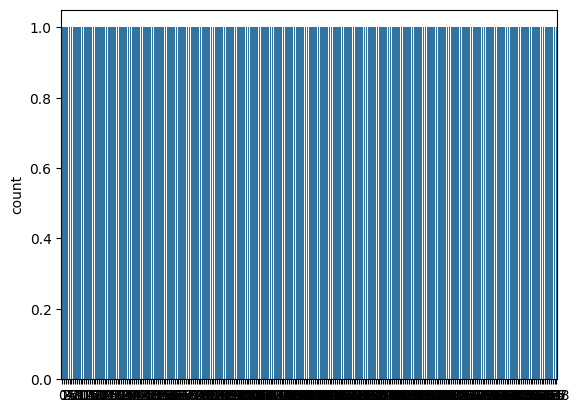

In [18]:
sns.countplot(y)

In [19]:
np.unique(y, return_counts=True)

(array([0, 1]), array([160, 109]))

## Normalização dos dados

In [20]:
X[0].max(), X[0].min()

(np.uint8(255), np.uint8(0))

In [21]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

In [22]:
X[0].max(), X[0].min()

(np.float64(1.0000000000000002), np.float64(0.0))

In [23]:
X[1]

array([0.9947644 , 0.99479167, 0.99479167, ..., 0.99559471, 0.99595142,
       0.9950495 ], shape=(16384,))

## Bases de treinamento e teste

In [24]:
X.shape

(269, 16384)

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X_treinamento, X_teste, y_treinamento, y_teste = train_test_split(X, y, test_size = 0.2, random_state = 1)

In [27]:
X_treinamento.shape, y_treinamento.shape

((215, 16384), (215,))

In [28]:
X_teste.shape, y_teste.shape

((54, 16384), (54,))

## Construção e treinamento da rede neural

In [46]:
128 * 128

16384

In [47]:
(16384 + 2) / 2

8193.0

In [48]:
# 16384 -> 8193 -> 8193
network1 = tf.keras.models.Sequential()
network1.add(tf.keras.layers.Dense(input_shape = (16384,), units = 8193, activation='relu'))
network1.add(tf.keras.layers.Dense(units = 8193, activation='relu'))
network1.add(tf.keras.layers.Dense(units = 1, activation='sigmoid'))

c:\Users\lucas\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [49]:
network1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8193)           │   134,242,305 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8193)           │    67,133,442 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201,383,941 (768.22 MB)

 Trainable params: 201,383,941 (768.22 MB)

 Non-trainable params: 0 (0.00 B)

In [50]:
# https://keras.io/api/optimizers/
# https://keras.io/api/losses/
network1.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [51]:
historico = network1.fit(X_treinamento, y_treinamento, epochs = 50)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.4335 - loss: 201.7133
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.4466 - loss: 14.0567
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.5441 - loss: 2.4469
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.4915 - loss: 0.8690
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.5414 - loss: 0.7193
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.5953 - loss: 0.6837
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.5813 - loss: 0.6823
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.6725 - loss: 0.6699
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.6352 - loss: 0.6378
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.6439 - loss: 0.6322
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.6662 - loss: 0.6226
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.6963 - loss: 0.5647
Epoch 13/5

## Avaliação da rede neural

In [52]:
historico.history.keys()

dict_keys(['accuracy', 'loss'])

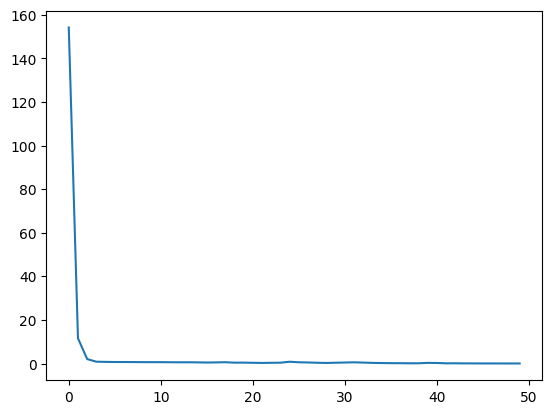

In [53]:
plt.plot(historico.history['loss']);

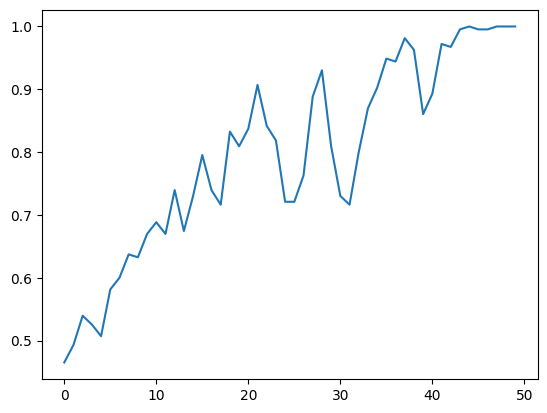

In [54]:
plt.plot(historico.history['accuracy']);

In [55]:
X_teste.shape

(54, 16384)

In [56]:
previsoes = network1.predict(X_teste)
previsoes

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step


array([[0.00522028],
       [0.9969184 ],
       [0.01775601],
       [0.04933219],
       [0.5791632 ],
       [0.01847679],
       [0.99759436],
       [0.7424222 ],
       [0.25932166],
       [0.91037285],
       [0.03241135],
       [0.9998247 ],
       [0.74557203],
       [0.71755123],
       [0.07166551],
       [0.00996652],
       [0.10175707],
       [0.7823556 ],
       [0.05097257],
       [0.00270566],
       [0.00232173],
       [0.6876746 ],
       [0.00498688],
       [0.06261992],
       [0.02503236],
       [0.65756595],
       [0.0102268 ],
       [0.0203686 ],
       [0.13157521],
       [0.93965155],
       [0.2733559 ],
       [0.9961395 ],
       [0.75312376],
       [0.00253056],
       [0.9994731 ],
       [0.00768972],
       [0.4977748 ],
       [0.00439452],
       [0.10693304],
       [0.00372413],
       [0.94234765],
       [0.90999556],
       [0.042486  ],
       [0.00978021],
       [0.00779914],
       [0.14606515],
       [0.9524877 ],
       [0.010

In [57]:
# 0 False Bart
# 1 True Homer
previsoes = (previsoes > 0.5)
previsoes

array([[False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [False]])

In [58]:
y_teste

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 1])

In [59]:
from sklearn.metrics import accuracy_score
accuracy_score(y_teste, previsoes)

0.7222222222222222

In [60]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_teste, previsoes)
cm

array([[23,  5],
       [10, 16]])

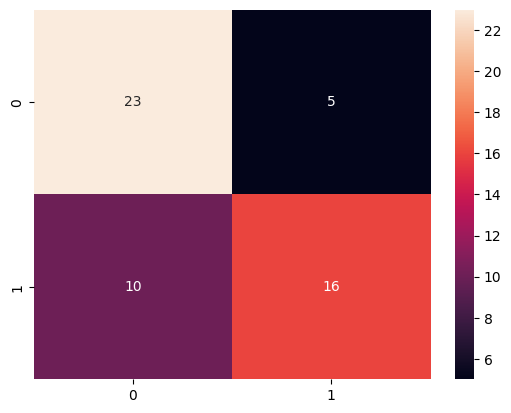

In [61]:
sns.heatmap(cm, annot=True);

In [62]:
from sklearn.metrics import classification_report
print(classification_report(y_teste, previsoes))

              precision    recall  f1-score   support

           0       0.70      0.82      0.75        28
           1       0.76      0.62      0.68        26

    accuracy                           0.72        54
   macro avg       0.73      0.72      0.72        54
weighted avg       0.73      0.72      0.72        54



## Salvar e carregar a rede neural

In [63]:
model_json = network1.to_json()
with open('network1.json', 'w') as json_file:
  json_file.write(model_json)

In [64]:
from keras.models import save_model
network1_saved = save_model(network1, 'weights1.hdf5')

In [65]:
with open('network1.json') as json_file:
  json_saved_model = json_file.read()
json_saved_model

'{"module": "keras", "class_name": "Sequential", "config": {"name": "sequential", "trainable": true, "dtype": {"module": "keras", "class_name": "DTypePolicy", "config": {"name": "float32"}, "registered_name": null}, "layers": [{"module": "keras.layers", "class_name": "InputLayer", "config": {"batch_shape": [null, 16384], "dtype": "float32", "sparse": false, "ragged": false, "name": "input_layer"}, "registered_name": null}, {"module": "keras.layers", "class_name": "Dense", "config": {"name": "dense", "trainable": true, "dtype": {"module": "keras", "class_name": "DTypePolicy", "config": {"name": "float32"}, "registered_name": null}, "units": 8193, "activation": "relu", "use_bias": true, "kernel_initializer": {"module": "keras.initializers", "class_name": "GlorotUniform", "config": {"seed": null}, "registered_name": null}, "bias_initializer": {"module": "keras.initializers", "class_name": "Zeros", "config": {}, "registered_name": null}, "kernel_regularizer": null, "bias_regularizer": null

In [67]:
network1_loaded = tf.keras.models.model_from_json(json_saved_model)
network1_loaded.load_weights('weights1.hdf5')
network1_loaded.compile(loss = 'binary_crossentropy', optimizer = 'Adam', metrics = ['accuracy'])

In [68]:
network1_loaded.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8193)           │   134,242,305 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8193)           │    67,133,442 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201,383,941 (768.22 MB)

 Trainable params: 201,383,941 (768.22 MB)

 Non-trainable params: 0 (0.00 B)

## Classificação de uma única imagem

In [69]:
X_teste[0], y_teste[0]

(array([1., 1., 1., ..., 1., 1., 1.], shape=(16384,)), np.int64(0))

In [70]:
X_teste[0].shape

(16384,)

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

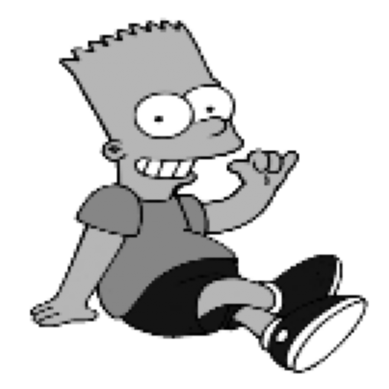

In [79]:
# use matplotlib (plt) to show the image in the notebook
plt.imshow(X_teste[0].reshape(128,128), cmap='gray', vmin=0, vmax=1)
plt.axis('off')

In [82]:
imagem_teste = X_teste[0]
imagem_teste = scaler.inverse_transform(imagem_teste.reshape(1, -1))

In [83]:
imagem_teste

array([[255., 255., 255., ..., 255., 255., 255.]], shape=(1, 16384))

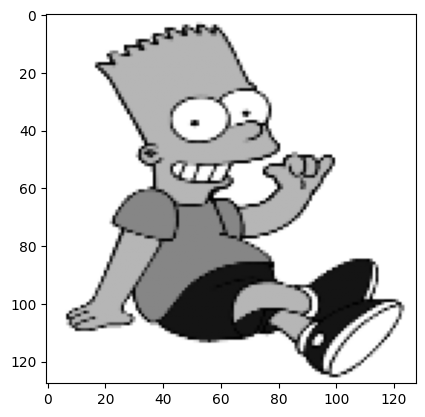

In [84]:
plt.imshow(imagem_teste.reshape(128,128), cmap='gray', vmin=0, vmax=255)

In [85]:
network1_loaded.predict(imagem_teste)[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


np.float32(0.0)

In [86]:
if network1_loaded.predict(imagem_teste)[0][0] < 0.5:
  print('Bart')
else:
  print('Homer')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Bart


# Abordagem 2: extração de características

## Extrator de características

In [11]:
arquivos = [os.path.join(diretorio, f) for f in sorted(os.listdir(diretorio))]
print(arquivos)

['C:\\Lusca\\WorkSpace\\Curso-Visao-Computacional\\homer_bart_1\\.DS_Store', 'C:\\Lusca\\WorkSpace\\Curso-Visao-Computacional\\homer_bart_1\\bart1.bmp', 'C:\\Lusca\\WorkSpace\\Curso-Visao-Computacional\\homer_bart_1\\bart10.bmp', 'C:\\Lusca\\WorkSpace\\Curso-Visao-Computacional\\homer_bart_1\\bart100.bmp', 'C:\\Lusca\\WorkSpace\\Curso-Visao-Computacional\\homer_bart_1\\bart101.bmp', 'C:\\Lusca\\WorkSpace\\Curso-Visao-Computacional\\homer_bart_1\\bart102.bmp', 'C:\\Lusca\\WorkSpace\\Curso-Visao-Computacional\\homer_bart_1\\bart103.bmp', 'C:\\Lusca\\WorkSpace\\Curso-Visao-Computacional\\homer_bart_1\\bart104.bmp', 'C:\\Lusca\\WorkSpace\\Curso-Visao-Computacional\\homer_bart_1\\bart105.bmp', 'C:\\Lusca\\WorkSpace\\Curso-Visao-Computacional\\homer_bart_1\\bart106.bmp', 'C:\\Lusca\\WorkSpace\\Curso-Visao-Computacional\\homer_bart_1\\bart108.bmp', 'C:\\Lusca\\WorkSpace\\Curso-Visao-Computacional\\homer_bart_1\\bart109.bmp', 'C:\\Lusca\\WorkSpace\\Curso-Visao-Computacional\\homer_bart_1\\bart

In [12]:
export = 'boca,calca,sapatos,camisa,calcao,tenis,classe\n'

In [13]:
mostrar_imagens = False
caracteristicas = []

In [32]:
100 * 200

20000

In [33]:
(2000 / 20000) * 100

10.0

In [14]:
for imagem_caminho in arquivos:
  #print(imagem_caminho)
  try:
    imagem_original = cv2.imread(imagem_caminho)
    (H, W) = imagem_original.shape[:2]
  except:
    continue

  imagem_alterada = imagem_original.copy()
  imagem_caracteristicas = []
  imagem_nome = os.path.basename(os.path.normpath(imagem_caminho))
  boca = calca = sapato = 0
  camisa = calcao = tenis = 0

  if imagem_nome.startswith('b'):
    classe = 0
  else:
    classe = 1

  for altura in range(0, H):
    for largura in range(0, W):
      # RGB -> BGR
      azul = imagem_alterada.item(altura, largura, 0)
      verde = imagem_alterada.item(altura, largura, 1)
      vermelho = imagem_alterada.item(altura, largura, 2)

      # Homer - marrom da boca
      if (azul >= 95 and azul <= 140 and verde >= 160 and verde <= 185 and vermelho >= 175 and vermelho <= 205):
        imagem_alterada[altura, largura] = [0, 255, 255]
        boca += 1

      # Homer - azul da calça
      if (azul >= 150 and azul <= 180 and verde >= 98 and verde <= 120 and vermelho >= 0 and vermelho <= 90):
        imagem_alterada[altura, largura] = [0, 255, 255]
        calca += 1

      # Homer - cinza dos sapatos
      if altura > (H / 2):
        if (azul >= 25 and azul <= 45 and verde >= 25 and verde <= 45 and vermelho >= 25 and vermelho <= 45):
          imagem_alterada[altura, largura] = [0, 255, 255]
          sapato += 1

      # Bart - laranja da camisa
      if (azul >= 11 and azul <= 50 and verde >= 85 and verde <= 105 and vermelho >= 240 and vermelho <= 255):
        imagem_alterada[altura, largura] = [0, 255, 128]
        camisa += 1

      # Bart - azul do calção
      if (azul >= 125 and azul <= 170 and verde >= 0 and verde <= 12 and vermelho >= 0 and vermelho <= 20):
        imagem_alterada[altura, largura] = [0, 255, 128]
        calcao += 1

      # Bart - azul do tênis
      if altura > (H / 2):
        if (azul >= 125 and azul <= 170 and verde >= 0 and verde <= 12 and vermelho >= 0 and vermelho <= 20):
          imagem_alterada[altura, largura] = [0, 255, 128]
          tenis += 1

  boca = round((boca / (H * W)) * 100, 9)
  calca = round((calca / (H * W)) * 100, 9)
  sapato = round((sapato / (H * W)) * 100, 9)
  camisa = round((camisa / (H * W)) * 100, 9)
  calcao = round((calcao / (H * W)) * 100, 9)
  tenis = round((tenis / (H * W)) * 100, 9)

  imagem_caracteristicas.append(boca)
  imagem_caracteristicas.append(calca)
  imagem_caracteristicas.append(sapato)
  imagem_caracteristicas.append(camisa)
  imagem_caracteristicas.append(calcao)
  imagem_caracteristicas.append(tenis)
  imagem_caracteristicas.append(classe)

  caracteristicas.append(imagem_caracteristicas)

  print('Homer boca: ', imagem_caracteristicas[0], ' - Homer calça: ', imagem_caracteristicas[1], ' - Homer sapato: ', imagem_caracteristicas[2])
  print('Bart camisa: ', imagem_caracteristicas[3], ' - Bart calção: ', imagem_caracteristicas[4], ' - Bart tênis: ', imagem_caracteristicas[5])

  f = (",".join([str(item) for item in imagem_caracteristicas]))
  export += f + '\n'

  if mostrar_imagens == True:
    imagem_alterada = cv2.cvtColor(imagem_alterada, cv2.COLOR_BGR2RGB)
    imagem_original = cv2.cvtColor(imagem_original, cv2.COLOR_BGR2RGB)
    figura, im = plt.subplots(1, 2)
    im[0].imshow(imagem_original)
    im[0].axis('off')
    im[1].imshow(imagem_alterada)
    im[1].axis('off')
    plt.show()


  #cv2_imshow(imagem_original)
  #print(H, W)
  #print(imagem_nome)

Homer boca:  0.0  - Homer calça:  0.0  - Homer sapato:  0.114799225
Bart camisa:  6.886101887  - Bart calção:  3.495204355  - Bart tênis:  3.495204355
Homer boca:  0.0  - Homer calça:  0.0  - Homer sapato:  0.11007847
Bart camisa:  5.004901113  - Bart calção:  3.183888705  - Bart tênis:  3.183888705
Homer boca:  0.0  - Homer calça:  0.0  - Homer sapato:  0.182518631
Bart camisa:  5.264620437  - Bart calção:  5.029682961  - Bart tênis:  5.029682961
Homer boca:  0.0  - Homer calça:  0.480168257  - Homer sapato:  0.080028043
Bart camisa:  0.0  - Bart calção:  0.0  - Bart tênis:  0.0
Homer boca:  0.0  - Homer calça:  0.0  - Homer sapato:  0.029707562
Bart camisa:  8.978929368  - Bart calção:  3.459119497  - Bart tênis:  3.459119497
Homer boca:  0.0  - Homer calça:  0.0  - Homer sapato:  0.053304904
Bart camisa:  6.75432362  - Bart calção:  0.948827292  - Bart tênis:  0.948827292
Homer boca:  0.249585206  - Homer calça:  0.0  - Homer sapato:  0.019853369
Bart camisa:  9.693407263  - Bart ca

In [15]:
export

'boca,calca,sapatos,camisa,calcao,tenis,classe\n0.0,0.0,0.114799225,6.886101887,3.495204355,3.495204355,0\n0.0,0.0,0.11007847,5.004901113,3.183888705,3.183888705,0\n0.0,0.0,0.182518631,5.264620437,5.029682961,5.029682961,0\n0.0,0.480168257,0.080028043,0.0,0.0,0.0,0\n0.0,0.0,0.029707562,8.978929368,3.459119497,3.459119497,0\n0.0,0.0,0.053304904,6.75432362,0.948827292,0.948827292,0\n0.249585206,0.0,0.019853369,9.693407263,4.104683977,4.104683977,0\n0.0,0.0,0.181208054,0.0,0.0,0.0,0\n0.0,0.0,0.148868778,0.0,0.0,0.0,0\n0.0,0.0,0.114762211,9.594752524,7.522715548,7.522715548,0\n0.0,0.0,0.138655462,0.0,0.0,0.0,0\n0.0,0.0,0.02400947,19.545383481,0.0,0.0,0\n0.00307645,0.0,0.0,6.495154592,5.599138594,5.599138594,0\n0.001317263,0.0,0.087817515,0.0,0.0,0.0,0\n0.0,0.0,0.032184591,8.395721925,0.0,0.0,0\n0.02105732,0.0,0.008503918,8.915750471,0.0,0.0,0\n0.0,0.0,0.081055114,11.095816228,4.525111363,4.525111363,0\n0.0,0.0,0.08757526,10.493254773,3.183296307,3.183296307,0\n0.0,0.0,0.043806812,9.5635746

In [17]:
with open('features.csv', 'w') as file:
  for linha in export:
    file.write(linha)
file.closed

True

In [18]:
dataset = pd.read_csv('features.csv')
dataset

,boca,calca,sapatos,camisa,calcao,tenis,classe
0,0.000000,0.000000,0.114799,6.886102,3.495204,3.495204,0
1,0.000000,0.000000,0.110078,5.004901,3.183889,3.183889,0
2,0.000000,0.000000,0.182519,5.264620,5.029683,5.029683,0
3,0.000000,0.480168,0.080028,0.000000,0.000000,0.000000,0
4,0.000000,0.000000,0.029708,8.978929,3.459119,3.459119,0
...,...,...,...,...,...,...,...
264,6.485412,0.000000,0.171985,0.000000,0.000000,0.000000,1
265,0.000000,0.000000,0.161637,0.000000,0.000000,0.000000,1
266,4.264975,0.000000,0.329940,0.000000,0.000000,0.000000,1
267,1.429133,0.000000,0.034559,0.000000,0.000000,0.000000,1


## Bases de treinamento e teste

In [19]:
X = dataset.iloc[:, 0:6].values
X

array([[ 0.        ,  0.        ,  0.11479923,  6.88610189,  3.49520435,
         3.49520435],
       [ 0.        ,  0.        ,  0.11007847,  5.00490111,  3.18388871,
         3.18388871],
       [ 0.        ,  0.        ,  0.18251863,  5.26462044,  5.02968296,
         5.02968296],
       ...,
       [ 4.26497522,  0.        ,  0.32993967,  0.        ,  0.        ,
         0.        ],
       [ 1.42913348,  0.        ,  0.03455866,  0.        ,  0.        ,
         0.        ],
       [ 0.853902  , 13.74424774,  0.16177802,  0.        ,  0.        ,
         0.        ]], shape=(269, 6))

In [20]:
y = dataset.iloc[:, 6].values
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1])

In [21]:
from sklearn.model_selection import train_test_split
X_treinamento, X_teste, y_treinamento, y_teste = train_test_split(X, y, test_size = 0.2, random_state = 1)

In [22]:
X_treinamento.shape, y_treinamento.shape

((215, 6), (215,))

In [23]:
X_teste.shape, y_teste.shape

((54, 6), (54,))

## Construção e treinamento da rede neural

In [24]:
(6 + 2) / 2

4.0

In [42]:
# 6 -> 4 -> 4 -> 4
network2 = tf.keras.Sequential()
network2.add(tf.keras.layers.Dense(input_shape = (6,), units = 4, activation='relu'))
network2.add(tf.keras.layers.Dense(units=4, activation='relu'))
network2.add(tf.keras.layers.Dense(units=4, activation='relu'))
network2.add(tf.keras.layers.Dense(units = 1, activation='sigmoid'))

In [43]:
network2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 4)              │            28 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73 (292.00 B)

 Trainable params: 73 (292.00 B)

 Non-trainable params: 0 (0.00 B)

In [44]:
network2.compile(optimizer='Adam', loss='binary_crossentropy', metrics = ['accuracy'])

In [57]:
historico = network2.fit(X_treinamento, y_treinamento, epochs = 200)

Epoch 1/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9315 - loss: 0.1555 
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9183 - loss: 0.2139 
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9167 - loss: 0.1795 
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9309 - loss: 0.1793 
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9186 - loss: 0.1754 
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9386 - loss: 0.1574 
Epoch 7/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9374 - loss: 0.1658 
Epoch 8/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9048 - loss: 0.1795 
Epoch 9/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9264 - loss: 0.1698 
Epoch 10/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9421 - loss: 0.1548 
Epoch 11/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9133 - loss: 0.1809 
Epoch 12/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9266 - los

## Avaliação da rede neural

In [58]:
historico.history.keys()

dict_keys(['accuracy', 'loss'])

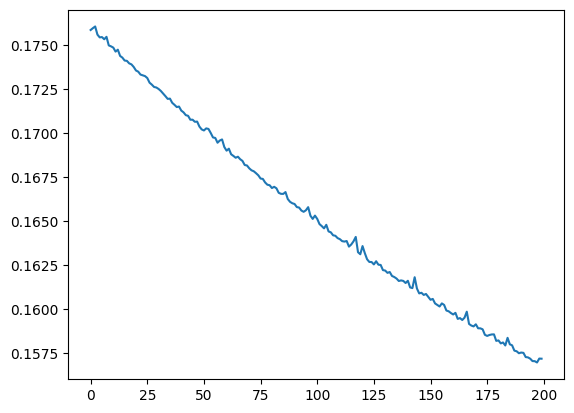

In [59]:
plt.plot(historico.history['loss']);

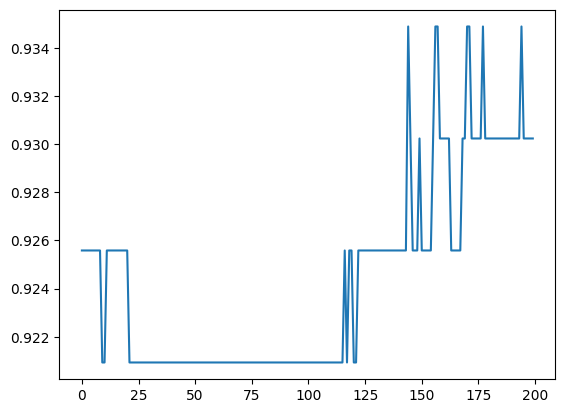

In [60]:
plt.plot(historico.history['accuracy']);

In [61]:
X_teste.shape

(54, 6)

In [62]:
previsoes = network2(X_teste)
previsoes

<tf.Tensor: shape=(54, 1), dtype=float32, numpy=
array([[1.48953088e-13],
       [9.99961138e-01],
       [1.44673962e-04],
       [2.93207735e-01],
       [4.48371566e-06],
       [9.99994040e-01],
       [1.06870685e-20],
       [5.81138920e-06],
       [1.22984190e-07],
       [5.14721307e-07],
       [1.07386825e-03],
       [1.00000000e+00],
       [9.46239948e-01],
       [7.43883511e-14],
       [2.76232630e-01],
       [1.00000000e+00],
       [9.13741231e-01],
       [9.99908984e-01],
       [8.41665951e-06],
       [1.41877070e-04],
       [2.36037280e-20],
       [9.99999881e-01],
       [9.80580270e-01],
       [1.21819166e-10],
       [2.10470896e-18],
       [1.00000000e+00],
       [6.01193130e-01],
       [1.47262099e-05],
       [9.99914527e-01],
       [1.00000000e+00],
       [9.81534481e-01],
       [1.00000000e+00],
       [1.00000000e+00],
       [6.27296865e-01],
       [1.00000000e+00],
       [9.81452107e-01],
       [1.60743213e-07],
       [9.37612441e-08],
 

In [63]:
previsoes = previsoes > 0.5
previsoes

<tf.Tensor: shape=(54, 1), dtype=bool, numpy=
array([[False],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [ True]])>

In [64]:
y_teste

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 1])

In [65]:
from sklearn.metrics import accuracy_score
accuracy_score(y_teste, previsoes)

0.9259259259259259

In [66]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_teste, previsoes)
cm

array([[26,  2],
       [ 2, 24]])

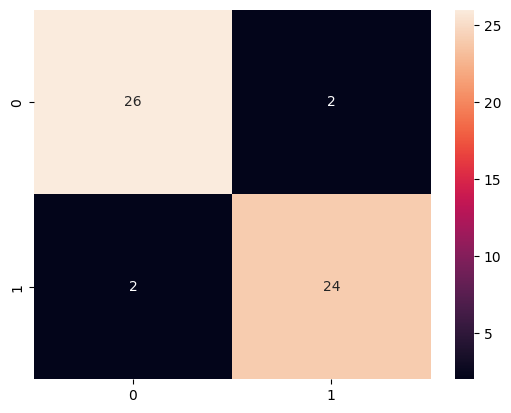

In [67]:
sns.heatmap(cm, annot=True);

In [68]:
from sklearn.metrics import classification_report
print(classification_report(y_teste, previsoes))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        28
           1       0.92      0.92      0.92        26

    accuracy                           0.93        54
   macro avg       0.93      0.93      0.93        54
weighted avg       0.93      0.93      0.93        54



## Salvar, carregar e classificar uma única imagem

In [69]:
model_json = network2.to_json()
with open('network2.json','w') as json_file:
  json_file.write(model_json)

In [75]:
%pip install keras

from tensorflow.keras.models import save_model
network2_saved = save_model(network2, 'weights2.hdf5')


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [76]:
with open('network2.json', 'r') as json_file:
  json_saved_model = json_file.read()
json_saved_model

'{"module": "keras", "class_name": "Sequential", "config": {"name": "sequential_4", "trainable": true, "dtype": {"module": "keras", "class_name": "DTypePolicy", "config": {"name": "float32"}, "registered_name": null}, "layers": [{"module": "keras.layers", "class_name": "InputLayer", "config": {"batch_shape": [null, 6], "dtype": "float32", "sparse": false, "ragged": false, "name": "input_layer_4"}, "registered_name": null}, {"module": "keras.layers", "class_name": "Dense", "config": {"name": "dense_15", "trainable": true, "dtype": {"module": "keras", "class_name": "DTypePolicy", "config": {"name": "float32"}, "registered_name": null}, "units": 4, "activation": "relu", "use_bias": true, "kernel_initializer": {"module": "keras.initializers", "class_name": "GlorotUniform", "config": {"seed": null}, "registered_name": null}, "bias_initializer": {"module": "keras.initializers", "class_name": "Zeros", "config": {}, "registered_name": null}, "kernel_regularizer": null, "bias_regularizer": null

In [78]:
network2_loaded = tf.keras.models.model_from_json(json_saved_model)
network2_loaded.load_weights('weights2.hdf5')
network2_loaded.compile(loss = 'binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [79]:
network2_loaded.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 4)              │            28 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73 (292.00 B)

 Trainable params: 73 (292.00 B)

 Non-trainable params: 0 (0.00 B)

In [80]:
imagem_teste = X_teste[0]
imagem_teste

array([3.07645000e-03, 0.00000000e+00, 0.00000000e+00, 6.49515459e+00,
       5.59913859e+00, 5.59913859e+00])

In [81]:
imagem_teste.shape

(6,)

In [82]:
imagem_teste = imagem_teste.reshape(1,-1)
imagem_teste.shape

(1, 6)

In [83]:
network2_loaded.predict(imagem_teste)[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


np.float32(1.4895314e-13)

In [84]:
if network2_loaded.predict(imagem_teste)[0][0] < 0.5:
  print('Bart')
else:
  print('Homer')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Bart
